In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, SGDRegressor, Lasso, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.svm import SVR, LinearSVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, ExtraTreesRegressor

from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

In [12]:
dataset = pd.read_csv(r"C:\Users\priya\Downloads\Housing\Housing.csv")
dataset

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [13]:
x = dataset.iloc[  : , :-1  ].values
y = dataset.iloc[  : , -1  ].values
dataset

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [15]:
dataset.duplicated().sum()

np.int64(0)

In [17]:

dataset.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

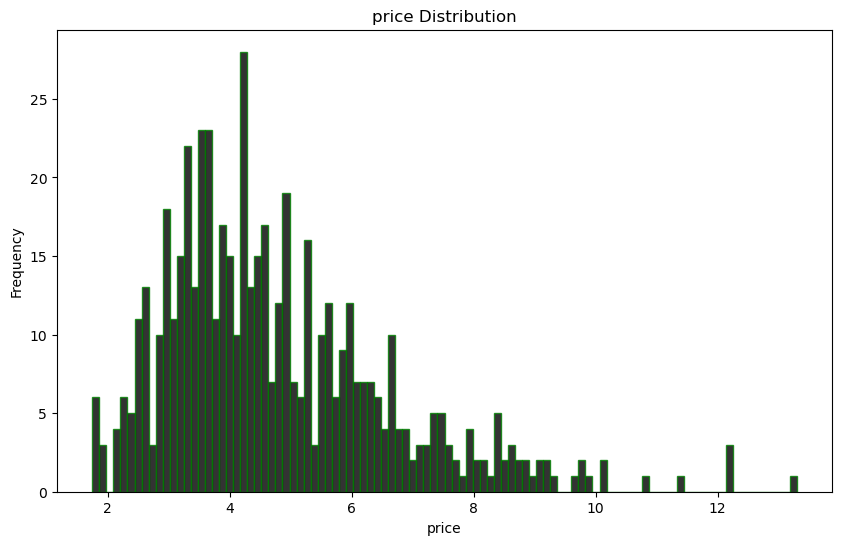

In [19]:
plt.figure(figsize=(10, 6))
plt.hist(dataset['price']/1000000, bins=100, color='black', alpha=0.8, edgecolor='green')
plt.title('price Distribution')
plt.xlabel('price')
plt.ylabel('Frequency')
plt.show()

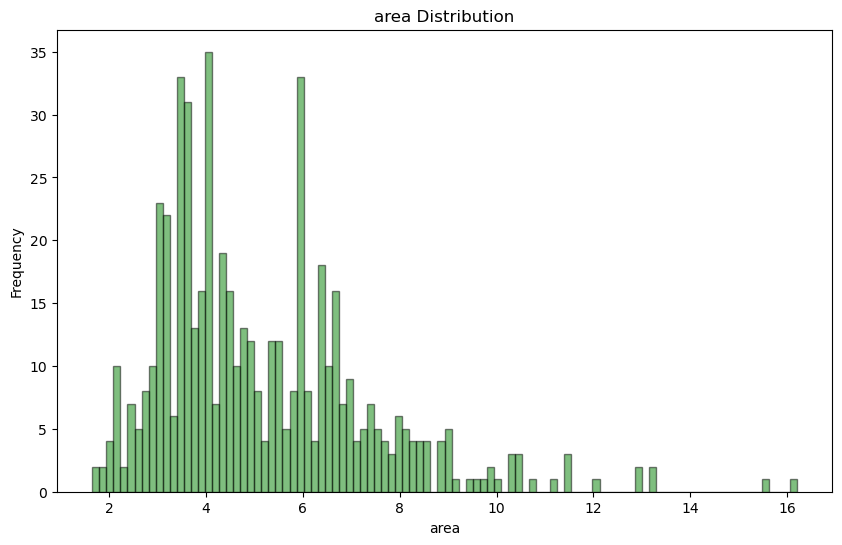

In [20]:
plt.figure(figsize=(10, 6))
plt.hist(dataset['area']/1000, bins=100, color='green', alpha=0.5, edgecolor='black')
plt.title('area Distribution')
plt.xlabel('area')
plt.ylabel('Frequency')
plt.show()

Text(0, 0.5, 'Price')

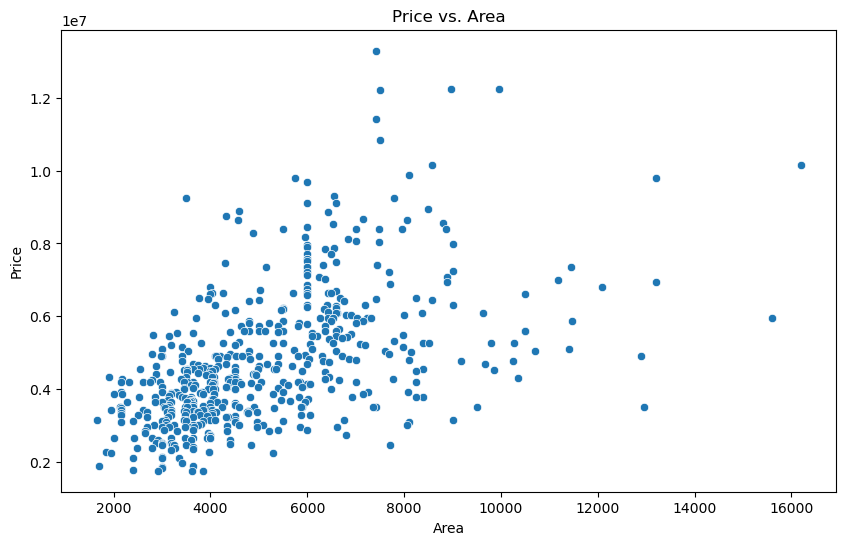

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dataset, x='area', y='price')  
plt.title('Price vs. Area')
plt.xlabel('Area')
plt.ylabel('Price')


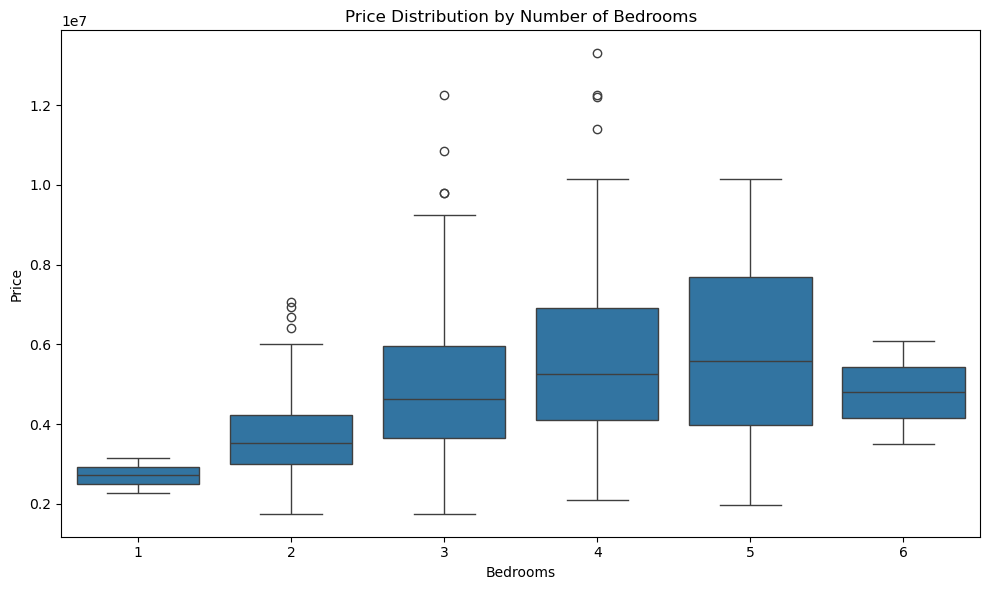

In [22]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='bedrooms', y='price', data=dataset)

plt.title('Price Distribution by Number of Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

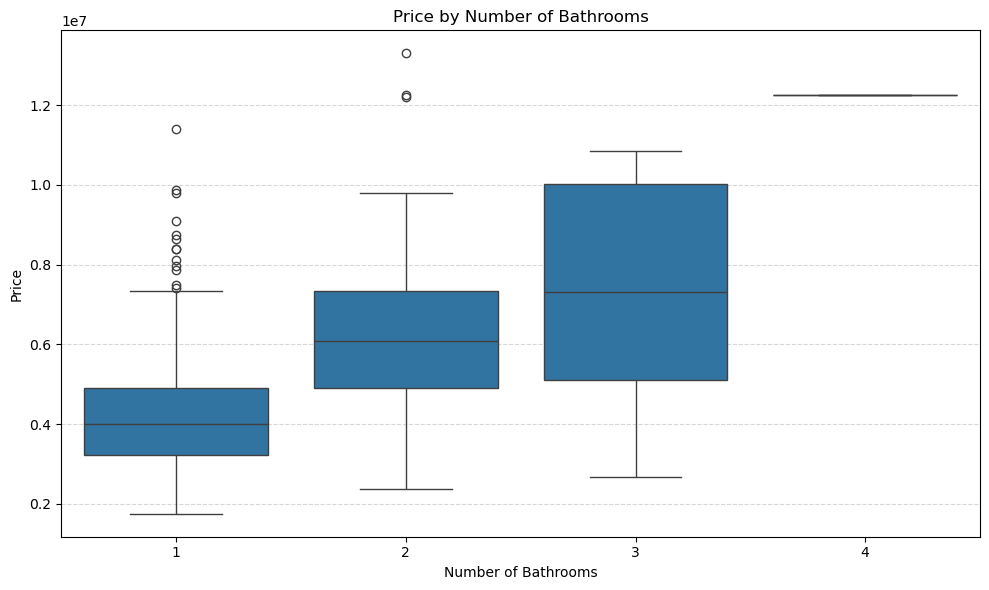

In [23]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=dataset, x='bathrooms', y='price')

plt.title('Price by Number of Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Price')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


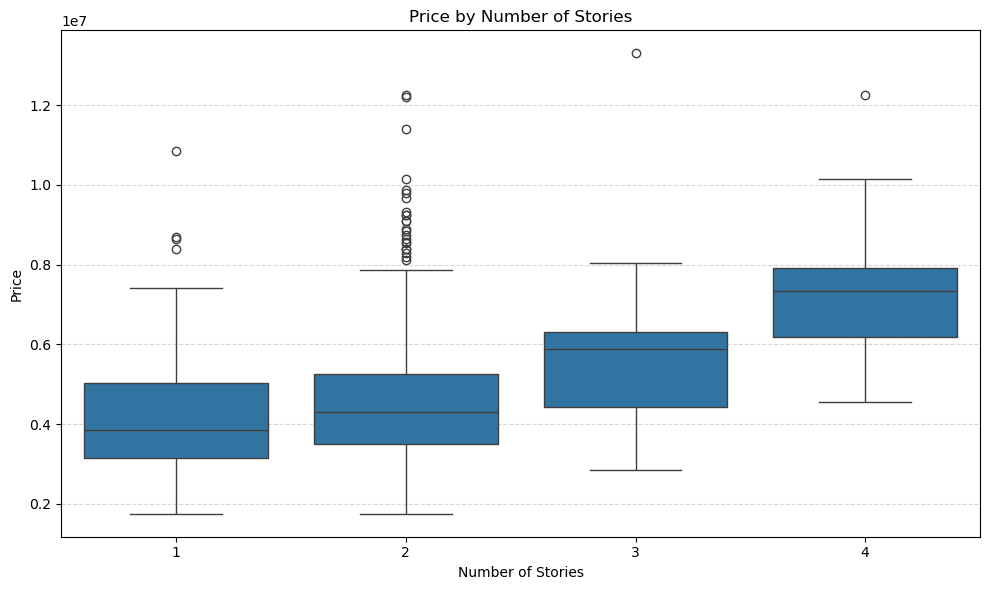

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=dataset, x='stories', y='price')
plt.title('Price by Number of Stories')
plt.xlabel('Number of Stories')
plt.ylabel('Price')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\priya\AppData\Local\Temp\ipykernel_6060\3748051939.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='mainroad', y='price', data=dataset, palette=palette)


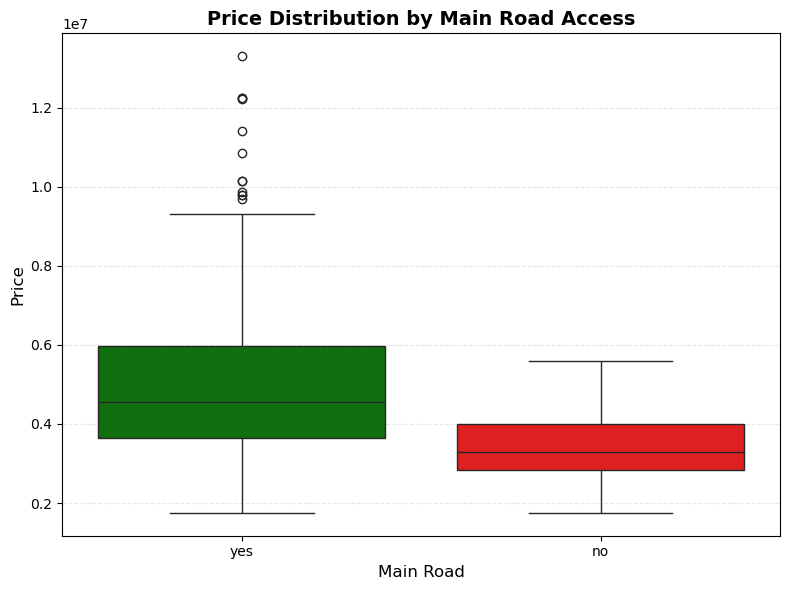

In [25]:
palette = {'yes': 'green', 'no': 'red'}
plt.figure(figsize=(8, 6))
sns.boxplot(x='mainroad', y='price', data=dataset, palette=palette)

plt.title('Price Distribution by Main Road Access', fontsize=14, fontweight='bold')
plt.xlabel('Main Road', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


C:\Users\priya\AppData\Local\Temp\ipykernel_6060\1676638342.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='guestroom', y='price', data=dataset, palette=palette)


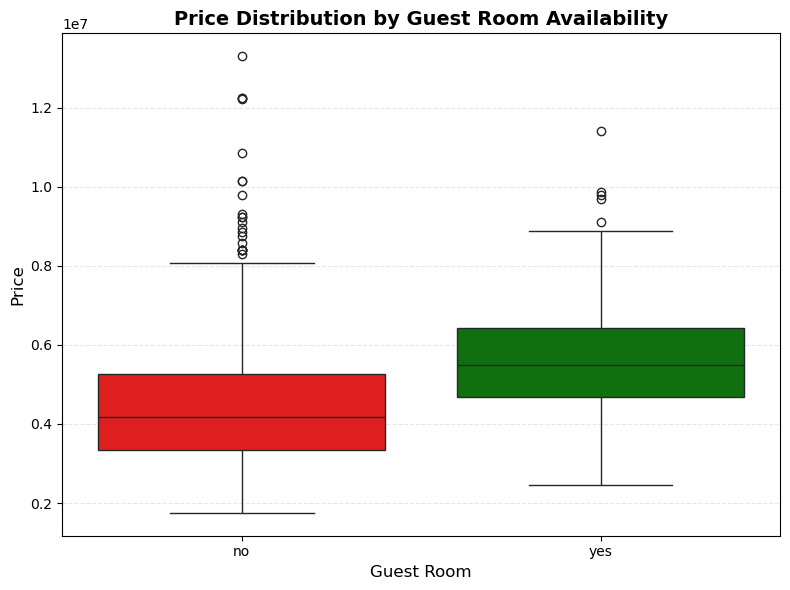

In [26]:
palette = {'yes': 'green', 'no': 'red'}

plt.figure(figsize=(8, 6))
sns.boxplot(x='guestroom', y='price', data=dataset, palette=palette)

plt.title('Price Distribution by Guest Room Availability', fontsize=14, fontweight='bold')
plt.xlabel('Guest Room', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


C:\Users\priya\AppData\Local\Temp\ipykernel_6060\1828013670.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='hotwaterheating', y='price', data=dataset, palette=palette)


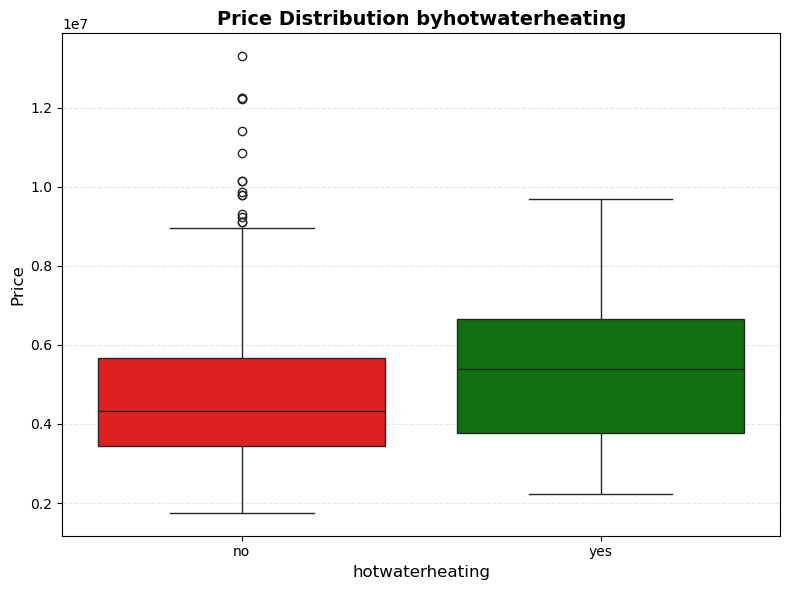

In [27]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='hotwaterheating', y='price', data=dataset, palette=palette)

plt.title('Price Distribution byhotwaterheating', fontsize=14, fontweight='bold')
plt.xlabel('hotwaterheating', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


C:\Users\priya\AppData\Local\Temp\ipykernel_6060\2901310919.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='airconditioning', y='price', data=dataset, palette={'yes': 'green', 'no': 'red'})


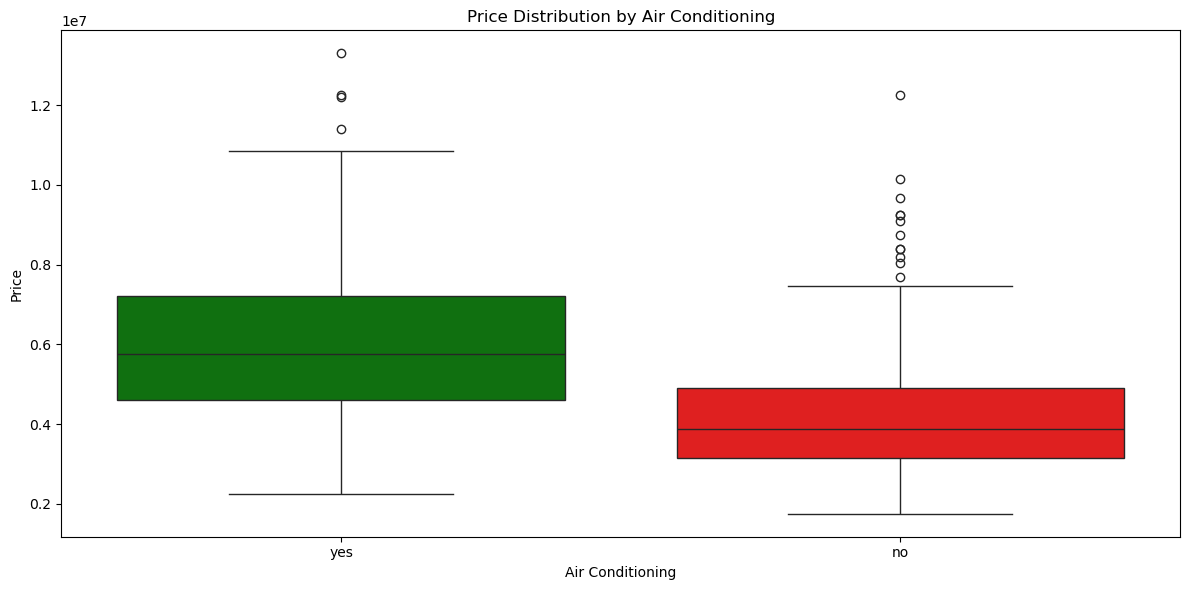

In [28]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='airconditioning', y='price', data=dataset, palette={'yes': 'green', 'no': 'red'})
plt.title('Price Distribution by Air Conditioning')
plt.xlabel('Air Conditioning')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

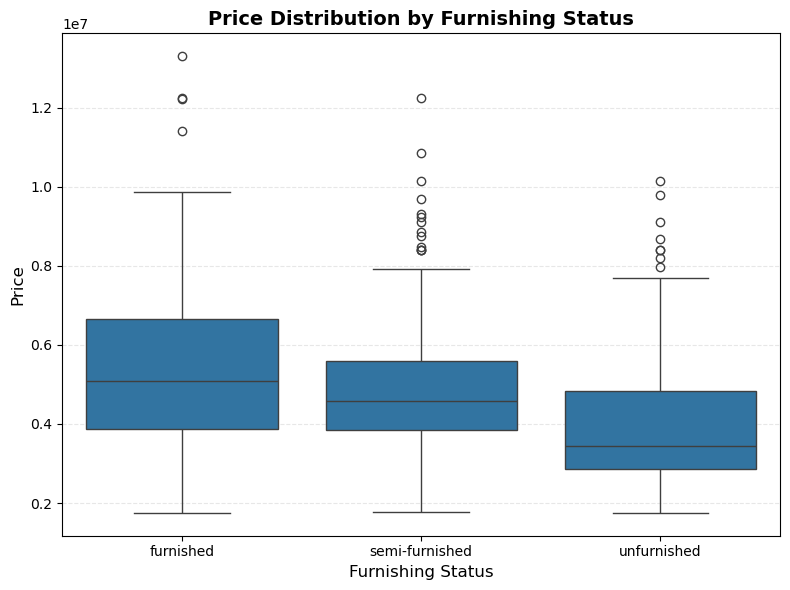

In [29]:
custom_palette = {
    'furnished': '#00C49A',
    'semi-furnished': '#FFA600',
    'unfurnished': '#FF6E54'
}

plt.figure(figsize=(8, 6))
sns.boxplot(x='furnishingstatus', y='price', data=dataset)

plt.title('Price Distribution by Furnishing Status', fontsize=14, fontweight='bold')
plt.xlabel('Furnishing Status', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

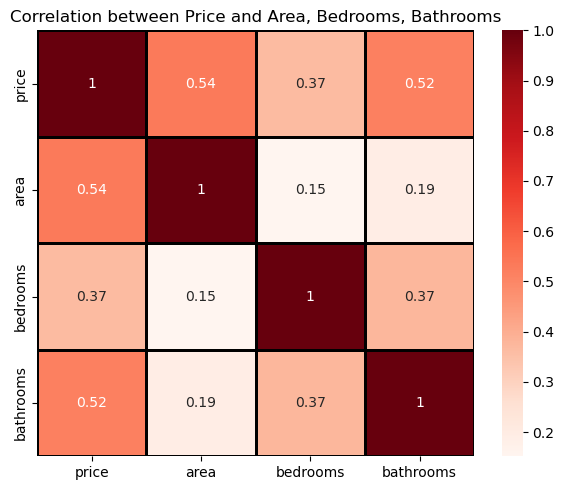

In [30]:
data_plotting = dataset[['price', 'area', 'bedrooms', 'bathrooms']].corr(method='pearson')

plt.figure(figsize=(6, 5))
sns.heatmap(data_plotting, cmap='Reds', linecolor='black', linewidths=1, annot=True)

plt.title('Correlation between Price and Area, Bedrooms, Bathrooms')
plt.tight_layout()
plt.show()

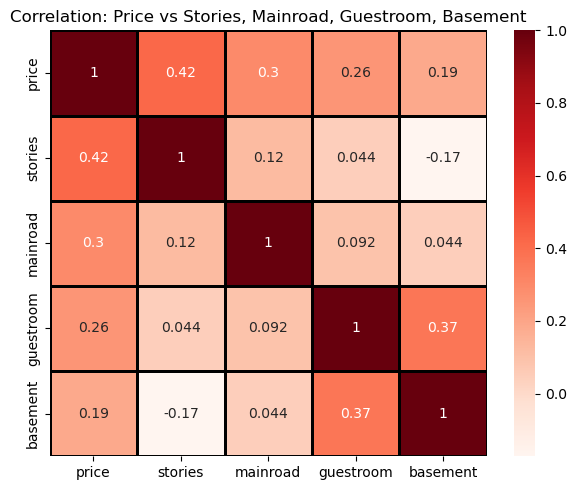

In [32]:
dataset_encoded = dataset.copy()
dataset_encoded['mainroad'] = dataset_encoded['mainroad'].map({'yes': 1, 'no': 0})
dataset_encoded['guestroom'] = dataset_encoded['guestroom'].map({'yes': 1, 'no': 0})
dataset_encoded['basement'] = dataset_encoded['basement'].map({'yes': 1, 'no': 0})

data_plotting = dataset_encoded[['price', 'stories', 'mainroad', 'guestroom', 'basement']].corr(method='pearson')

plt.figure(figsize=(6, 5))
sns.heatmap(data_plotting, cmap='Reds', linecolor='black', linewidths=1, annot=True)

plt.title('Correlation: Price vs Stories, Mainroad, Guestroom, Basement')
plt.tight_layout()
plt.show()

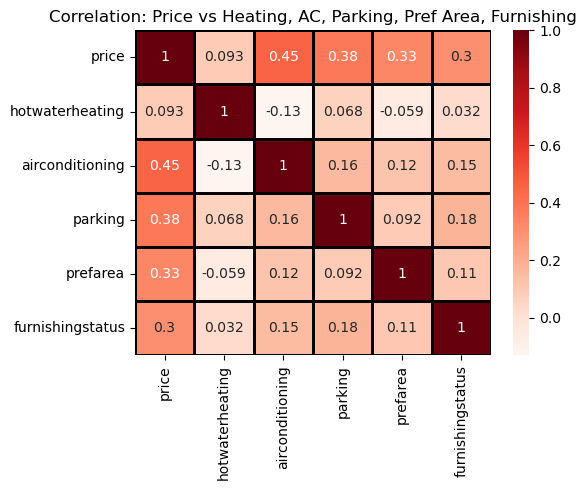

In [35]:
dataset_encoded = dataset.copy()

dataset_encoded['hotwaterheating'] = dataset_encoded['hotwaterheating'].map({'yes': 1, 'no': 0})
dataset_encoded['airconditioning'] = dataset_encoded['airconditioning'].map({'yes': 1, 'no': 0})
dataset_encoded['prefarea'] = dataset_encoded['prefarea'].map({'yes': 1, 'no': 0})

dataset_encoded['furnishingstatus'] =  dataset_encoded['furnishingstatus'].map({
    'unfurnished': 0,
    'semi-furnished': 1,
    'furnished': 2
})
data_plotting = dataset_encoded[['price', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']].corr(method='pearson')

plt.figure(figsize=(6, 5))
sns.heatmap(data_plotting, cmap='Reds', linecolor='black', linewidths=1, annot=True)

plt.title('Correlation: Price vs Heating, AC, Parking, Pref Area, Furnishing')
plt.tight_layout()
plt.show()

In [36]:
grouped1 = df_encoded.groupby(['mainroad','prefarea', 'stories'])['price'].mean()
pd.DataFrame(grouped1)

price
mainroad prefarea stories              
no       no       1        3.070560e+06
                  2        3.684932e+06
                  3        4.480000e+06
         yes      1        2.233000e+06
                  2        3.640000e+06
yes      no       1        4.004050e+06
                  2        4.638076e+06
                  3        5.485421e+06
                  4        6.991670e+06
         yes      1        5.439281e+06
                  2        6.018323e+06
                  3        6.030500e+06
                  4        7.979222e+06

In [37]:
grouped2 = df_encoded.groupby(['basement','airconditioning', 'hotwaterheating'])['price'].mean()
pd.DataFrame(grouped2)

price
basement airconditioning hotwaterheating              
no       no              no               3.812536e+06
                         yes              5.019467e+06
         yes             no               5.993095e+06
                         yes              3.640000e+06
yes      no              no               4.654427e+06
                         yes              6.674111e+06
         yes             no               6.081197e+06

In [38]:
dataset['mainroad'] = dataset['mainroad'].map({'yes': 1, 'no': 0})
dataset['guestroom'] = dataset['guestroom'].map({'yes': 1, 'no': 0})
dataset['basement'] = dataset['basement'].map({'yes': 1, 'no': 0})
dataset['hotwaterheating'] = dataset['hotwaterheating'].map({'yes': 1, 'no': 0})
dataset['airconditioning'] = dataset['airconditioning'].map({'yes': 1, 'no': 0})
dataset['prefarea'] = dataset['prefarea'].map({'yes': 1, 'no': 0})
dataset['furnishingstatus'] = dataset['furnishingstatus'].map({
    'unfurnished': 0,
    'semi-furnished': 1,
    'furnished': 2
})

In [39]:
X = dataset.drop(columns=['price'])
y = dataset['price']

In [40]:
X

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,1,0,0,0,1,2,1,2
1,8960,4,4,4,1,0,0,0,1,3,0,2
2,9960,3,2,2,1,0,1,0,0,2,1,1
3,7500,4,2,2,1,0,1,0,1,3,1,2
4,7420,4,1,2,1,1,1,0,1,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,0,1,0,0,2,0,0
541,2400,3,1,1,0,0,0,0,0,0,0,1
542,3620,2,1,1,1,0,0,0,0,0,0,0
543,2910,3,1,1,0,0,0,0,0,0,0,2


In [41]:
y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

In [42]:
scaler = MinMaxScaler()
X['area'] = scaler.fit_transform(X[['area']])

In [43]:
X_train , X_test , y_train ,y_test = train_test_split(X,y,train_size=0.8, shuffle=True, random_state=True)

In [44]:
X_train 

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
272,0.166667,3,1,1,1,1,1,0,0,2,0,1
40,0.336770,3,1,2,1,0,1,0,1,0,1,2
326,0.168385,4,1,1,0,0,1,0,0,0,0,0
441,0.186942,3,1,2,1,0,0,0,0,0,0,0
511,0.105155,3,1,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
129,0.674227,3,1,3,1,0,0,0,0,2,1,1
144,0.209622,4,1,2,1,1,1,0,1,1,0,2
72,0.231615,3,1,4,1,0,0,0,1,0,1,0
235,0.276976,3,1,2,1,1,0,0,1,1,0,1


In [45]:
from sklearn.linear_model import LinearRegression, SGDRegressor, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pr_lr = lr.predict(X_test)
mae_linear = mean_absolute_error(y_test, y_pr_lr)
mse_linear = mean_squared_error(y_test, y_pr_lr)


# SGD Regressor
sgd = SGDRegressor()
sgd.fit(X_train, y_train)
y_pred_sgd = sgd.predict(X_test)
mae_sgd = mean_absolute_error(y_test, y_pred_sgd)
mse_sgd = mean_squared_error(y_test, y_pred_sgd)


# Lasso Regression
lasso = Lasso()
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
# Ridge Regression
ridge = Ridge()
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)


In [46]:
comparison = pd.DataFrame({
    'Model': ['SGDRegressor', 'Lasso Regression', 'Ridge Regression', 'Linear Regression'],
    'MAE': [mae_sgd, mae_lasso, mae_ridge, mae_linear],
    'MSE': [mse_sgd, mse_lasso, mse_ridge, mse_linear],
   
})

In [47]:
pd.DataFrame(comparison)

,Model,MAE,MSE
0,SGDRegressor,925454.380981,1.732893e+12
1,Lasso Regression,898628.241553,1.602775e+12
2,Ridge Regression,899975.840129,1.611492e+12
3,Linear Regression,898629.295037,1.602774e+12


In [48]:
svm_models = {
    "SVR‑RBF": make_pipeline(StandardScaler(), SVR(kernel="rbf", C=10, epsilon=0.1)),
    "LinearSVR": make_pipeline(StandardScaler(), LinearSVR(C=1.0, random_state=42, max_iter=20000))
}

svm_results = []

for name, model in svm_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
  
    svm_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
      
    })

pd.DataFrame(svm_results).sort_values("RMSE")

,Model,MAE,RMSE
0,SVR‑RBF,1.496433e+06,2.091369e+06
1,LinearSVR,4.758151e+06,5.180656e+06



Model Performance:
               Model         MAE        RMSE  R2 Score (%)
0  Linear Regression   487782.44   742895.53         89.08
1   Lasso Regression   487784.16   742898.13         89.08
2   Ridge Regression   491993.62   750011.46         88.87
3      SGD Regressor   503971.18   769275.97         88.29
4         Linear SVR  5007108.55  5488697.85       -496.01


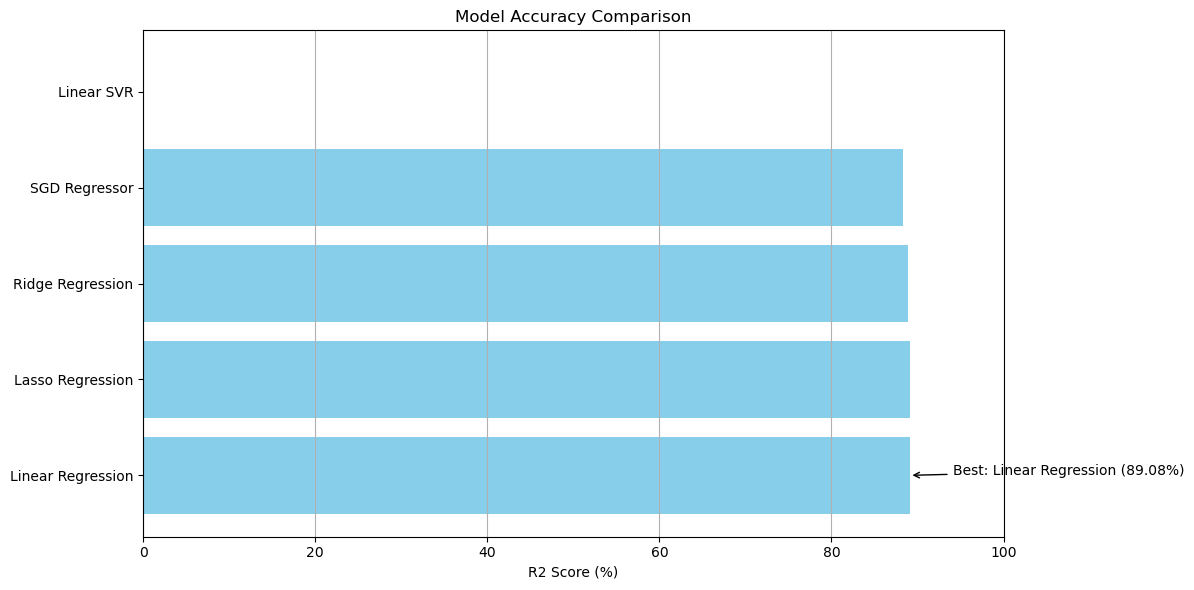

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, SGDRegressor, Lasso, Ridge
from sklearn.svm import LinearSVR




# Feature Engineering
dataset['area_per_room'] = dataset['area'] / (dataset['bedrooms'] +dataset['bathrooms'])
dataset['price_per_area'] = dataset['price'] / dataset['area']

# Encode Categorical Variables
dataset_encoded = pd.get_dummies(dataset, drop_first=True)

# Features and Target
X = dataset_encoded.drop(columns=['price'])
y = dataset_encoded['price']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ========================
# Define Models
# ========================
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    return mae, mse, r2

models = {
    'Linear Regression': LinearRegression(),
    'SGD Regressor': SGDRegressor(),
    'Lasso Regression': Lasso(),
    'Ridge Regression': Ridge(),
    'Linear SVR': LinearSVR(),
    
    
}

# ========================
# Train and Evaluate
# ========================
results = []

for name, model in models.items():
    mae, mse, r2 = evaluate_model(model, X_train, y_train, X_test, y_test)
    results.append({
        'Model': name,
        'MAE': round(mae, 2),
        'RMSE': round(np.sqrt(mse), 2),
        'R2 Score (%)': round(r2 * 100, 2)
    })

results_dataset = pd.DataFrame(results).sort_values(by='R2 Score (%)', ascending=False).reset_index(drop=True)

# ========================
# Display Results
# ========================
print("\nModel Performance:")
print(results_dataset)

plt.figure(figsize=(12, 6))
plt.barh(results_dataset['Model'], results_dataset['R2 Score (%)'], color='skyblue')
plt.xlabel('R2 Score (%)')
plt.title('Model Accuracy Comparison')
plt.xlim(0, 100)
plt.grid(axis='x')

best = results_dataset.iloc[0]
plt.annotate(f"Best: {best['Model']} ({best['R2 Score (%)']}%)",
             xy=(best['R2 Score (%)'], best.name),
             xytext=(best['R2 Score (%)'] + 5, best.name),
             arrowprops=dict(facecolor='black', arrowstyle='->'))

plt.tight_layout()
plt.show()